In [126]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

from llama_index.llms.ollama import Ollama

from tqdm import tqdm

tokenizer = AutoTokenizer.from_pretrained("ESGBERT/EnvironmentalBERT-environmental")
model = AutoModelForSequenceClassification.from_pretrained("ESGBERT/EnvironmentalBERT-environmental")

In [127]:
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0) # set device=0 to use GPU

[{'label': 'environmental', 'score': 0.9979760050773621}]


In [128]:


df = pd.read_csv("../data/chunks_raw_raptor.csv")

df_test = df.sample(n=100)


In [129]:

# Instantiate the Ollama model
llm = Ollama(model="qwen2.5:14b", timeout=30)

In [138]:
from llama_index.core import PromptTemplate

In [142]:
df_tv = pd.read_parquet("../data/video_extractions/latvia_tv_with_scores.parquet")

In [143]:
df_tv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   video_id          1825 non-null   object 
 1   channel_id        1825 non-null   object 
 2   duration          1825 non-null   int64  
 3   upload_date       1825 non-null   object 
 4   webpage_url       1825 non-null   object 
 5   has_audio         1825 non-null   bool   
 6   has_transcript    1825 non-null   bool   
 7   has_translation   1825 non-null   bool   
 8   raw_text          1825 non-null   object 
 9   translation       1825 non-null   object 
 10  score             1825 non-null   float64
 11  is_environmental  1825 non-null   bool   
dtypes: bool(4), float64(1), int64(1), object(6)
memory usage: 121.3+ KB


In [144]:
df_tv.head()

,video_id,channel_id,duration,upload_date,webpage_url,has_audio,has_transcript,has_translation,raw_text,translation,score,is_environmental
0,-0-x5hyqIc0,UCOSAAyJoybqsY5sZ76BaqFA,170,20240608,https://www.youtube.com/watch?v=-0-x5hyqIc0,True,True,True,"Saskaņā ar pēdējiem SKDS reitingiem, kas publi...",According to the latest SKDS ratings published...,0.007603,False
1,-0WQ3-Ql_tc,UCOSAAyJoybqsY5sZ76BaqFA,118,20240608,https://www.youtube.com/watch?v=-0WQ3-Ql_tc,True,True,True,"Mēreni, tā vēlētāju aktivitāti vērtē pieredzēj...","Moderately, experienced representatives of the...",0.006630,False
2,-0X0eGjKTNc,UCOSAAyJoybqsY5sZ76BaqFA,163,20240808,https://www.youtube.com/watch?v=-0X0eGjKTNc,True,True,True,Dodot piekrišanu dzelstaļa izbūvēja saima ir p...,"Granting consent for the railway construction,...",0.008218,False
3,-7PmnNEYIZ8,UCOSAAyJoybqsY5sZ76BaqFA,177,20240507,https://www.youtube.com/watch?v=-7PmnNEYIZ8,True,True,True,Asbestu saturošie būniecības materiāli Latvijā...,Asbestos-containing construction materials are...,0.995647,True
4,-7QgsYUNHC0,UCOSAAyJoybqsY5sZ76BaqFA,170,20240827,https://www.youtube.com/watch?v=-7QgsYUNHC0,True,True,True,Uz durvīm Latvijas universitādes ēkas aspazīja...,On the doors of the upper floors of the Univer...,0.006201,False


In [145]:
df_tv[["has_audio", "has_transcript", "has_translation"]].value_counts()

has_audio  has_transcript  has_translation
True       True            True               1825
Name: count, dtype: int64

<Axes: >

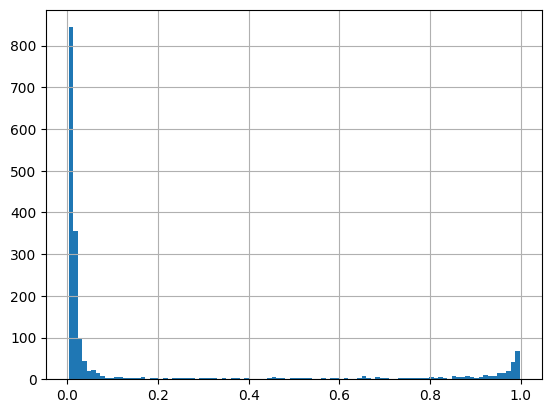

In [146]:
df_tv.score.hist(bins=100)

In [229]:
(df_tv.score > 0.8).sum(), df_tv.is_environmental.sum(), (df_tv.score > 0.5).sum()

(241, 309, 309)

As the EnvironmentalBERT-environmental takes in only 512 tokens as input there could be environment related transcripts that are excluded from the analysis.

This can be seen when we analyse the transcript lengths.

count     1825.000000
mean      3599.056438
std       3079.690562
min         10.000000
25%       1870.000000
50%       2381.000000
75%       3909.000000
max      30373.000000
Name: translation, dtype: float64

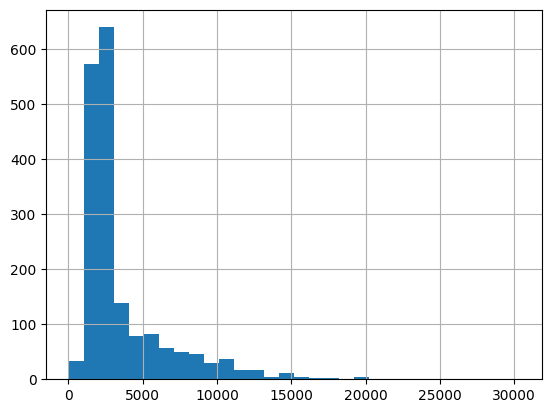

In [148]:
df_tv.translation.str.len().hist(bins=30)
df_tv.translation.str.len().describe()

In [149]:
def count_tokens(text):
    return len(tokenizer.encode_plus(text)["input_ids"])

def get_tokens(text):
    return tokenizer.encode_plus(text)["input_ids"]

def get_attention_mask(text):
    return tokenizer.encode_plus(text)["attention_mask"]

# df_tv["tokens"] = df_tv.translation.apply(get_tokens)
df_tv["n_tokens"] = df_tv.translation.apply(count_tokens)
# df_tv["attention_mask"] = df_tv.translation.apply(get_attention_mask)

Token indices sequence length is longer than the specified maximum sequence length for this model (550 > 512). Running this sequence through the model will result in indexing errors


In [150]:
df_tv["perc_tokens"] = 512 / np.where(df_tv["n_tokens"] > 512, df_tv["n_tokens"], 512)
# df_tv["confidence"] = np.exp(df_tv.perc_tokens) / np.exp(1)
# df_tv.confidence.describe()
# df_tv.confidence.hist(bins=100)


In [151]:
df_env = df_tv[df_tv.is_environmental].copy()
df_env.shape

(309, 14)

In [153]:
len(df_env.translation.iloc[0])


2071

In [155]:
is_environmental_prompt = """

You are an AI trained to analyze text for environmental themes. Your task is to examine the given text and determine if it discusses environmental subjects such as climate, the environment, or climate change.

Instructions:
1. Carefully read the provided text.
2. Look for keywords and concepts related to environmental topics, including but not limited to:
   - Climate change
   - Global warming
   - Greenhouse gases
   - Environmental protection
   - Biodiversity
   - Pollution
   - Renewable energy
   - Sustainability
   - Ecology
   - Conservation

3. Consider the overall context and main themes of the text.

4. Provide a yes/no answer on whether the text discusses environmental subjects.

5. If yes, briefly explain which environmental topics are mentioned and how they are addressed.

6. If no, briefly explain why you concluded the text does not focus on environmental subjects.

Text to analyze:
{transcription}

Please provide your analysis below:
"""

In [156]:


def classify_transcription(llm, transcription, prompt_template, template_args):
    # Format the prompt with the transcription
    formatted_prompt = prompt_template.format(transcription=transcription, **template_args)
    
    # Use the Ollama model to generate a response
    response = llm.complete(formatted_prompt)
    
    # Return the response text
    return response.text



In [157]:
env_template = PromptTemplate(is_environmental_prompt)
llm = Ollama(model="qwen2.5:14b", timeout=360)
classify_transcription(llm, df_env.translation.iloc[34], env_template, {})

'**Analysis:**\n\nThe provided text discusses weather conditions for Latvia, including temperature forecasts, precipitation predictions, and warnings about heatwaves. The text does not explicitly address environmental issues such as climate change, biodiversity loss, pollution, or sustainability.\n\nHowever, it indirectly touches upon environmental themes by mentioning a "yellow level warning for strong heat," which could be indicative of extreme weather events that are associated with broader discussions on climate change and its impacts. Nevertheless, the primary focus is on daily weather forecasts rather than addressing underlying environmental causes or solutions.\n\n**Conclusion:**\nYes, the text discusses an aspect related to environmental themes (heatwaves) but in a very indirect manner as part of a weather forecast.\n\n**Explanation:**\nThe text mentions "a yellow level warning for strong heat," which could be linked to climate change discussions since extreme heat events are b

In [165]:
from pydantic import BaseModel, Field
from typing import List, Union

ENVIRONMENTAL_ANALYSIS_PROMPT = """
Analyze the given text for themes related to sustainability and climate change. Determine if it significantly discusses these subjects, as we're identifying relevant documents for potential disinformation checks.

Instructions:
1. Read the provided text carefully.
2. Identify keywords and concepts related to sustainability and climate change, such as:
   - Climate change
   - Global warming
   - Greenhouse gas emissions
   - Carbon footprint
   - Renewable energy
   - Sustainable development
   - Climate mitigation and adaptation
   - Paris Agreement
   - Net-zero emissions
   - Climate policy

3. Evaluate the overall context and main themes.

4. Provide a boolean response (True/False) indicating significant discussion of sustainability or climate change issues.

5. For True responses: List the main sustainability or climate change topics mentioned.
   For False responses: Explain why the text doesn't primarily focus on these topics.

Text to analyze:
{text}

Output format:
is_climate_related: [True/False]
main_topics: [List of topics if True, "N/A" if False]
explanation: [Brief analysis explanation]
"""

class EnvironmentalAnalysis(BaseModel):
    is_climate_related: bool = Field(description="Boolean indicating whether the text significantly discusses sustainability or climate change issues")
    main_topics: Union[List[str], str] = Field(description="List of main sustainability or climate change topics mentioned, or 'N/A' if not climate-related")
    explanation: str = Field(description="Brief explanation of the analysis result")

In [166]:
from llama_index.core.output_parsers import PydanticOutputParser
from llama_index.core.program import LLMTextCompletionProgram


In [167]:

program = LLMTextCompletionProgram.from_defaults(
    output_parser=PydanticOutputParser(output_cls=EnvironmentalAnalysis),
    prompt_template_str=ENVIRONMENTAL_ANALYSIS_PROMPT,
    verbose=True,
    llm=llm
)

output = program(text=df_env.translation.iloc[34])


In [176]:
df_env.to_csv("../data/video_extractions/latvia_tv_env.csv", index=False)

In [177]:

from pydantic import ValidationError

results = {
    "is_climate_related": [],
    "main_topics": [],
    "explanation": []
}
for idx, row in tqdm(df_env.iterrows(), total=df_env.shape[0]):
    try:
        output = program(text=row.translation)
        results["is_climate_related"].append(output.is_climate_related)
        results["main_topics"].append(output.main_topics)
        results["explanation"].append(output.explanation)
    except ValidationError:
        results["is_climate_related"].append(None)
        results["main_topics"].append(None)
        results["explanation"].append(None)


df_env_analysis = pd.DataFrame(results)



100%|██████████| 309/309 [33:33<00:00,  6.52s/it]


In [184]:
df_env_analysis.index = df_env.video_id.tolist()


In [186]:
df_env_analysis = df_env.merge(df_env_analysis, left_on="video_id", right_index=True)

In [180]:
df_env_analysis.to_csv("../data/video_extractions/latvia_tv_env_analysis.csv", index=False)

In [198]:
df_env_analysis.is_climate_related.dropna().sum()

86

In [221]:
sublists = [sublist for sublist in df_env_analysis.main_topics.tolist() if sublist is not None and isinstance(sublist, list)]
items = [item for sublist in sublists for item in sublist]
words = " ".join(items)

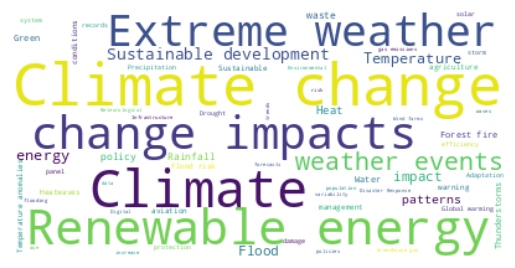

In [223]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(words)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [226]:
df_env_analysis = df_env_analysis.dropna()
df_env_analysis.loc[df_env_analysis.is_climate_related].to_csv("../data/video_extractions/latvia_tv_env_analysis_is_climate_related.csv", index=False)

In [237]:
df_env_analysis.loc[df_env_analysis.is_climate_related].translation.iloc[2]


"Good morning about the air temperature, because you may have heard that there is a strong heat wave in southern and eastern Europe, where in many places the air temperature exceeds 30 degrees Celsius, and in some places even reaches 40 degrees. We can see that these red air temperatures are not lower than 20 degrees Celsius, making it harder to ventilate spaces. It is also not very easy to sleep in such heat. Along with this heat comes dryness and an increased risk of forest fires in Greece, as well as some islands may have to limit water consumption this tourism season, while elsewhere the heat also brings intense thunderstorms and lightning. And we will also look at how warm the water is in the Adriatic Sea, I mentioned that the water with us is as warm as milk... Sigurd, it does not suit him from, look Sigurd… No? If you want to swim in milk that cannot be named, then please go to Croatia where the evening water temperature… You didn't mishear, the water temperature is 29.7 degrees

In [261]:
df_climate_claims = df_env_analysis.loc[df_env_analysis.is_climate_related].copy()

In [252]:

from typing import Literal, Optional

classification_prompt = """
You are an expert in disinformation on environmental topics, an expert in climate science, and knowledgeable about the IPCC. I will give you an excerpt of a 2-minute transcription from a TV or Radio stream. 
From this excerpt, list all the unique environmental facts/opinions (claims) that need fact-checking. For each claim, provide an initial analysis of whether it is disinformation or not, a score if it is disinformation, and a categorization of this allegation.
Select only claims on environmental themes (climate change, ecological transition, energy, biodiversity, pollution, pesticides, resources (water, minerals, etc.) and not on social and/or economic themes.
Return the result in JSON without any introductory or concluding sentences, with the following fields each time:

- "claim" - the allegation to potentially verify
- "context" - reformulation of the context in which this allegation was made (maximum 1 paragraph)
- "analysis" - initial analysis from the expert's point of view on the potential disinformation of this allegation based on the context
- "disinformation_score" - the disinformation score (see below)
- "disinformation_category" - the category of disinformation (see below)
- "pro_anti" - whether the allegation is more anti-ecology or pro-ecology (MUST be either "pro-ecology" or "anti-ecology", no other options allowed)
- "speaker" - name and function of the person who made the allegation if we have the information (otherwise "N/A")
- "contradiction" - if the allegation was contested in a dialogue, summarize the contradiction (otherwise "N/A")
- "quote" - the exact quote that corresponds to the allegation

For the scores "disinformation_score":
- "very low" = no problem, the allegation is not misleading or at risk. No need to investigate further
- "low" = allegation that would require verification and questioning, but on a subject that is not very important and significant in the context of ecological issues (example: lawnmowers)
- "medium" = problematic allegation on an important ecological subject (scientific, impacts, elections, politics, transport, agriculture, energy, food, democracy ...), which would really need to be verified, deconstructed, debunked, and questioned. Especially for fallacious opinions
- "high" = serious allegation, especially if it denies scientific consensus

For the categories of disinformation "disinformation_category":
- "consensus" = denial of scientific consensus
- "facts" = fact to verify, specify, or contextualize
- "narrative" = fallacious narrative or opinion that sows doubt (for example: "environmentalists want to take away our freedoms")
- "other"

For the "pro_anti" field:
- "pro-ecology" = the allegation supports or promotes environmental protection, sustainability, or climate action
- "anti-ecology" = the allegation opposes or undermines environmental protection, sustainability, or climate action
Note: You MUST choose either "pro-ecology" or "anti-ecology". If the allegation seems neutral, lean towards the side it slightly favors or could be interpreted as supporting. 
"N/A" and "neutral" are is NOT options.

<transcription>
{transcription}
</transcription>
"""


class ClaimAnalysis(BaseModel):
    claim: str = Field(..., description="The allegation to potentially verify")
    context: str = Field(..., description="Reformulation of the context in which this allegation was made (maximum 1 paragraph)")
    analysis: str = Field(..., description="Initial analysis from the expert's point of view on the potential disinformation of this allegation based on the context")
    disinformation_score: Literal["very low", "low", "medium", "high"] = Field(..., description="The disinformation score")
    disinformation_category: Literal["consensus", "facts", "narrative", "other"] = Field(..., description="The category of disinformation")
    pro_anti: Literal["pro-ecology", "anti-ecology"] = Field(..., description="Whether the allegation is more anti-ecology or pro-ecology")
    speaker: str = Field(..., description="Name and function of the person who made the allegation if we have the information (otherwise 'N/A')")
    contradiction: Optional[str] = Field(None, description="If the allegation was contested in a dialogue, summarize the contradiction (otherwise 'N/A')")
    quote: str = Field(..., description="The exact quote that corresponds to the allegation")

class TranscriptAnalysis(BaseModel):
    claims: list[ClaimAnalysis] = Field(..., description="List of claim analyses from the transcript")

In [255]:
from dotenv import load_dotenv

load_dotenv("../.env")

True

In [256]:
from llama_index.llms.openai import OpenAI

llm = OpenAI(model="gpt-4o")


In [264]:

classifier = LLMTextCompletionProgram.from_defaults(
    output_parser=PydanticOutputParser(output_cls=TranscriptAnalysis),
    prompt_template_str=classification_prompt,
    verbose=True,
    llm=llm
)

results = []
for idx, row in tqdm(df_climate_claims.iterrows(), total=df_climate_claims.shape[0]):
    output = classifier(transcription=row.translation)
    video_id = row.video_id
    record = {"video_id": video_id}
    for idx, claim in enumerate(output.claims):
        record.update({
            "claim_id": idx,
            "claim": claim.claim,
            "context": claim.context,
            "analysis": claim.analysis,
            "disinformation_score": claim.disinformation_score,
            "disinformation_category": claim.disinformation_category,
            "pro_anti": claim.pro_anti,
            "speaker": claim.speaker,
            "contradiction": claim.contradiction,
            "quote": claim.quote,
        })
    results.append(record)

100%|██████████| 86/86 [08:06<00:00,  5.66s/it]


In [265]:
df_analysis = pd.DataFrame.from_records(results)

In [267]:
df_analysis.disinformation_score.value_counts()

disinformation_score
low         33
very low    33
medium      20
Name: count, dtype: int64

In [285]:
df_analysis.to_csv("../data/video_extractions/latvia_tv_claim_all.csv", index=False)

In [270]:
df_serious_claims = df_analysis.loc[(df_analysis.disinformation_score=="medium") & (df_analysis.pro_anti=="anti-ecology")]

In [283]:
df_serious_claims.to_csv("../data/video_extractions/latvia_tv_claims.csv", index=False)

In [284]:
with open("../data/video_extractions/claim.txt", "w") as f:
    f.write(df_climate_claims.loc[df_climate_claims.video_id=="zVgFYQC5mtI"].translation.item())